In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet18
from sklearn.linear_model import Lasso

def load_image(path):
    img = Image.open(path).convert('RGB')
    return img.resize((224, 224))

def kmeans_numpy(X, n_clusters, max_iter=100, tol=1e-4):
    n = X.shape[0]
    # Randomly choose initial centroids from the data
    idx = np.random.choice(n, size=n_clusters, replace=False)
    centroids = X[idx].copy()
    labels = np.zeros(n, dtype=np.int32)
    for it in range(max_iter):
        # Assign each point to nearest centroid
        dists = np.linalg.norm(X[:, None] - centroids[None], axis=2)  # (n, k)
        new_labels = np.argmin(dists, axis=1)
        # Update centroids
        new_centroids = np.array([X[new_labels == j].mean(axis=0) 
                                  for j in range(n_clusters)])
        # If a cluster is empty, re‑initialize its centroid randomly
        for j in range(n_clusters):
            if not np.any(new_labels == j):
                new_centroids[j] = X[np.random.choice(n)]
        # Check convergence
        if np.allclose(centroids, new_centroids, atol=tol):
            labels = new_labels
            centroids = new_centroids
            break
        centroids = new_centroids
        labels = new_labels
    return centroids, labels


def kmeans_segments(image_uint8, n_segments=64, max_iter=50):
    H, W = image_uint8.shape[:2]
    xs, ys = np.meshgrid(np.arange(W), np.arange(H))
    features = np.column_stack([
        image_uint8.reshape(-1, 3).astype(float),
        ys.ravel().astype(float) * (255.0 / H) ,
        xs.ravel().astype(float) * (255.0 / W)
    ])
    centroids, labels = kmeans_numpy(features, n_segments, 
                                     max_iter=max_iter)
    return labels.reshape(H, W)

In [2]:
MODEL_PATH = "../model/resnet18-f37072fd.pth"    
np.random.seed(42)          
torch.manual_seed(42)      

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Load model architecture and weights
model = resnet18(weights=None)   
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print("Model loaded from", MODEL_PATH)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


Using device: cuda
Model loaded from ../model/resnet18-f37072fd.pth


# 1

In [ ]:
img = load_image('../data/Q1/cat.jpg')
img_np = np.array(img)
input_tensor = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probs = torch.nn.functional.softmax(output[0], dim=0)
    prob_282 = probs[282].item()
print(f"Probability for class 282: {prob_282:.4f}")

Probability for class 282: 0.9055


# 2

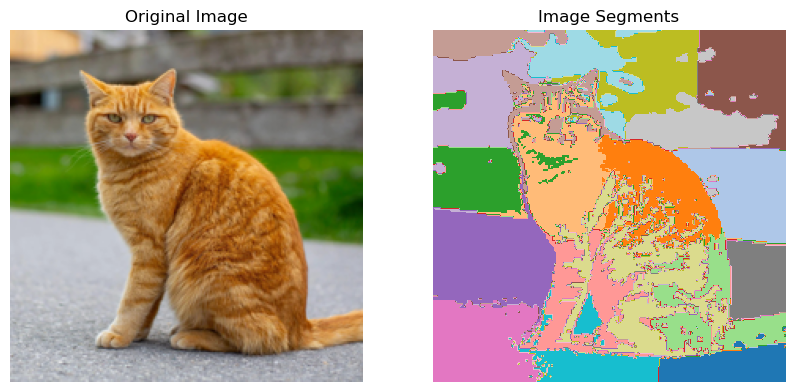

In [14]:
segments = kmeans_segments(img_np, n_segments=18)
num_segments = len(np.unique(segments))


plt.figure(figsize=(10, 5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(segments, cmap='tab20')
plt.title('Image Segments')
plt.axis('off')
plt.show()

# 3

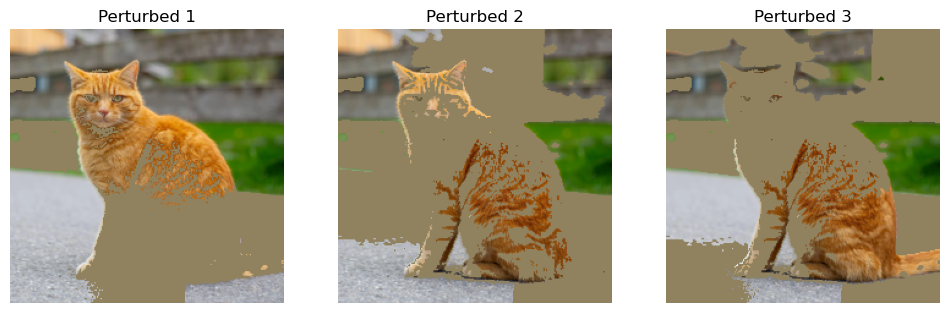

In [15]:
n_samples = 1000
Z = np.random.randint(0, 2, size=(n_samples, num_segments))

def perturb_image(image_arr, z_vector, segmentation_mask):
    perturbed = image_arr.copy()
    mean_color = image_arr.mean(axis=(0, 1)).astype(int)
    unique_segs = np.unique(segmentation_mask)
    
    for i, seg_id in enumerate(unique_segs):
        if i < len(z_vector) and z_vector[i] == 0:
            perturbed[segmentation_mask == seg_id] = mean_color
    return perturbed

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    axes[i].imshow(perturb_image(img_np, Z[i], segments))
    axes[i].set_title(f"Perturbed {i+1}")
    axes[i].axis('off')
plt.show()

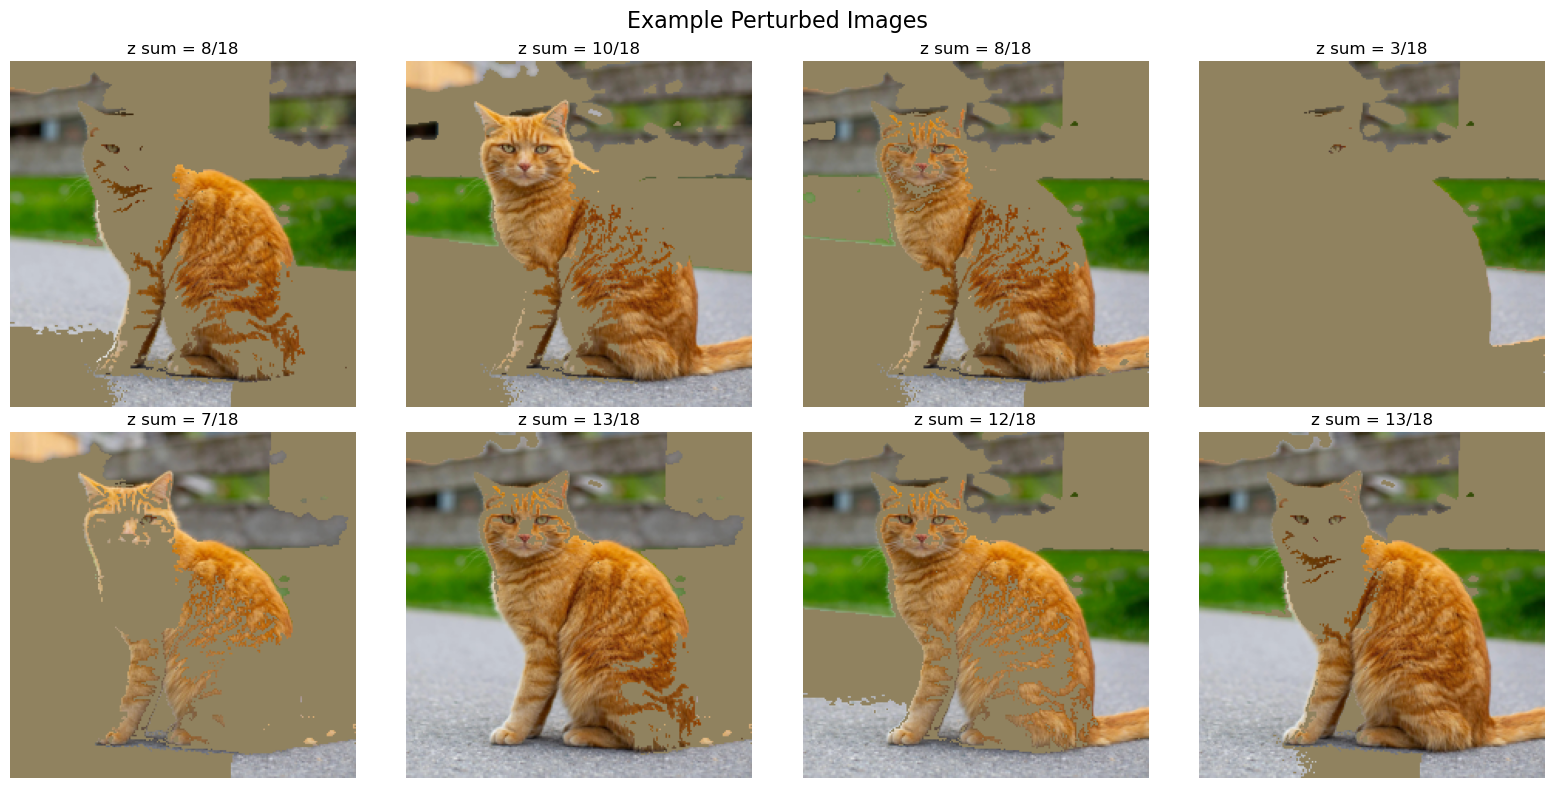

In [16]:
n_samples = 1000
Z = np.random.randint(0, 2, size=(n_samples, num_segments))

def perturb_image(image_arr, z_vector, segmentation_mask):
    perturbed = image_arr.copy()
    mean_color = image_arr.mean(axis=(0, 1)).astype(int)
    unique_segs = np.unique(segmentation_mask)
    
    for i, seg_id in enumerate(unique_segs):
        if i < len(z_vector) and z_vector[i] == 0:
            perturbed[segmentation_mask == seg_id] = mean_color
    return perturbed

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Example Perturbed Images", fontsize=16)

axes_flat = axes.flatten()

for i in range(8):
    z_vec = Z[i]
    z_sum = np.sum(z_vec)
    
    pert_img = perturb_image(img_np, z_vec, segments)
    
    axes_flat[i].imshow(pert_img)
    axes_flat[i].set_title(f"z sum = {z_sum}/18")
    axes_flat[i].axis('off')

plt.tight_layout()
plt.show()


# 4

In [7]:
d = num_segments
sigma = 0.25 * np.sqrt(d)
ones_vec = np.ones(d)
eps = 1e-8

dot_product = np.dot(Z, ones_vec)
norm_Z = np.linalg.norm(Z, axis=1)
norm_ones = np.linalg.norm(ones_vec)

dist_Z = 1 - (dot_product / (norm_Z * norm_ones + eps))
weights = np.exp(-(dist_Z**2) / (sigma**2))

# 5

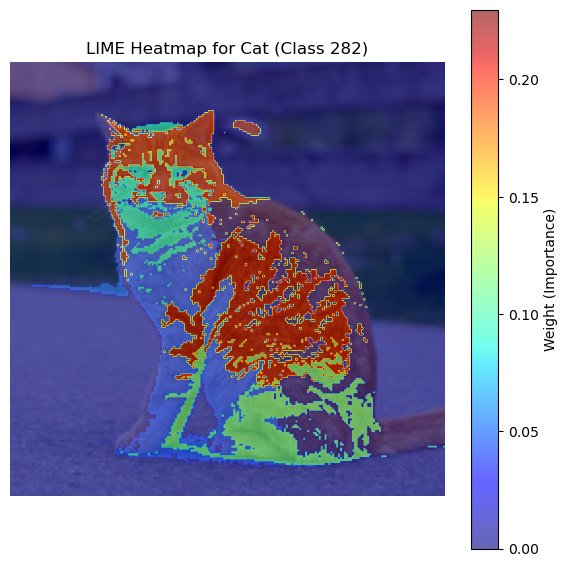

In [8]:
Y = np.zeros(n_samples)

for i in range(n_samples):
    pert_img = perturb_image(img_np, Z[i], segments)
    pert_pil = Image.fromarray(pert_img.astype('uint8'))
    pert_tensor = transform(pert_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(pert_tensor)
        p = torch.nn.functional.softmax(out[0], dim=0)
        Y[i] = p[282].item()

lasso = Lasso(alpha=0.1, fit_intercept=False)
lasso.fit(Z, Y, sample_weight=weights)
coefficients = lasso.coef_

heatmap = np.zeros_like(segments, dtype=float)
unique_segs = np.unique(segments)
for i, seg_id in enumerate(unique_segs):
    if i < len(coefficients):
        heatmap[segments == seg_id] = coefficients[i]

plt.figure(figsize=(7, 7))
plt.imshow(img_np)
plt.imshow(heatmap, cmap='jet', alpha=0.6)
plt.colorbar(label='Weight (Importance)')
plt.title("LIME Heatmap for Cat (Class 282)")
plt.axis('off')
plt.show()

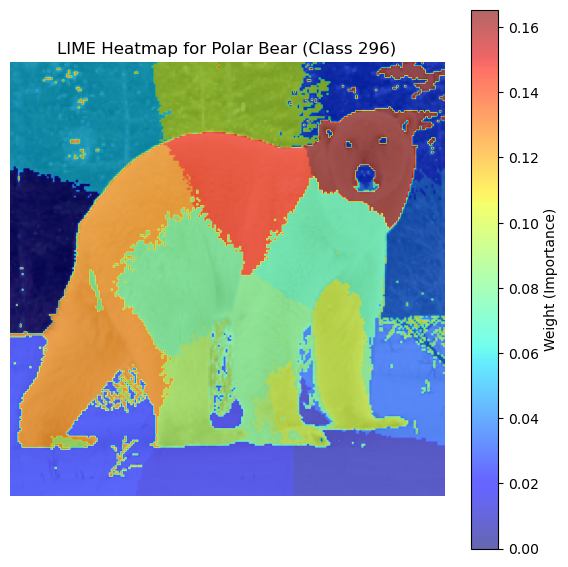

In [ ]:
img_pb = load_image('../data/Q1/polarBear.png')
img_np_pb = np.array(img_pb)
input_tensor_pb = transform(img_pb).unsqueeze(0).to(device)

segments_pb = kmeans_segments(img_np_pb, n_segments=18)
num_segments_pb = len(np.unique(segments_pb))

Z_pb = np.random.randint(0, 2, size=(n_samples, num_segments_pb))

d_pb = num_segments_pb
sigma_pb = 0.25 * np.sqrt(d_pb)
ones_vec_pb = np.ones(d_pb)
dot_product_pb = np.dot(Z_pb, ones_vec_pb)
norm_Z_pb = np.linalg.norm(Z_pb, axis=1)
norm_ones_pb = np.linalg.norm(ones_vec_pb)
dist_Z_pb = 1 - (dot_product_pb / (norm_Z_pb * norm_ones_pb + eps))
weights_pb = np.exp(-(dist_Z_pb**2) / (sigma_pb**2))

Y_pb = np.zeros(n_samples)
for i in range(n_samples):
    pert_img = perturb_image(img_np_pb, Z_pb[i], segments_pb)
    pert_pil = Image.fromarray(pert_img.astype('uint8'))
    pert_tensor = transform(pert_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(pert_tensor)
        p = torch.nn.functional.softmax(out[0], dim=0)
        Y_pb[i] = p[296].item()

lasso_pb = Lasso(alpha=0.1, fit_intercept=False)
lasso_pb.fit(Z_pb, Y_pb, sample_weight=weights_pb)
coefficients_pb = lasso_pb.coef_

heatmap_pb = np.zeros_like(segments_pb, dtype=float)
unique_segs_pb = np.unique(segments_pb)
for i, seg_id in enumerate(unique_segs_pb):
    if i < len(coefficients_pb):
        heatmap_pb[segments_pb == seg_id] = coefficients_pb[i]

plt.figure(figsize=(7, 7))
plt.imshow(img_np_pb)
plt.imshow(heatmap_pb, cmap='jet', alpha=0.6)
plt.colorbar(label='Weight (Importance)')
plt.title("LIME Heatmap for Polar Bear (Class 296)")
plt.axis('off')
plt.show()
